# Example: Running the Adaptive Rebalancing Engine Through 2025
In this example, we wire the maximum-utility allocator of the previous example into the L7a rebalancing engine and run it through calendar year 2025, a year the single index model parameters and the signal calibration never saw. The engine recomputes the market-state signal and the preference weights with a one-day lag, trades toward the Cobb–Douglas targets on a schedule under a turnover cap and a drawdown circuit breaker, pays transaction costs, and is scored on the realized path against static portfolios held from the first trading day.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Build a lagged decision rule:__ Compute the signal and the preference weights for every trading day of 2025 from prices through the previous day, and check in code that no same-day information leaks into the targets.
> * __Run and read the engine:__ Run the self-financing engine with the reallocation schedule, the turnover cap, and the drawdown limit; compare adaptive schedules with buy-and-hold minimum-variance, tangent, equal-weight, and SPY portfolios run through the same accounting; and read the wealth, weight, and intervention histories.
> * __Score a realized path:__ Assemble the realized-path scorecard (terminal wealth, portfolio NPV against the risk-free baseline, maximum drawdown, realized growth and Sharpe ratio, turnover, cost, interventions) and see what the trigger rules and the cost rate do to it.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`
Precompiling packages...
   4357.2 ms  ✓ VLQuantitativeFinancePackage
  1 dependency successfully precompiled in 7 seconds. 528 already precompiled.
  35 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, IJulia, InteractiveUtils, JLLWrappers, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, PrecompileTools, Preferences, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, ZMQ, ZeroMQ_jll, Zlib_jll, libsodium_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 344 dependents of these packages may trigger further precompilation to work with the unexpected versions.


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, and every signal we compute below is calibrated on it. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), which the engine trades through day by day.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive that the L6a estimation example saved, `SIMs-SP500-01-03-14-to-12-31-24.jld2`, [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/). The archive holds, for every security fitted against SPY on the training data, the estimated intercept $\hat{\alpha}_{i}$ and beta $\hat{\beta}_{i}$ (fields `alpha`, `beta`), the residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (field `training_variance`, units: inverse years squared), the coefficient of determination (field `r_squared`), and their standard errors; and, once for the whole archive, the training-period sample mean $g^{\prime}_{M}$ and sample variance $s^{2}_{g,M}$ of the market growth rate (keys `market_mean` and `market_variance`). We check that the archive uses the growth-rate variance convention of the lecture and store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the two market moments in the `g_market_mean::Float64` and `σ²_market::Float64` variables:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10]); growth definition: $(archive["growth_definition"])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31; growth definition: g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted


### Constants
Finally, let's specify some constants that we will use in our analysis. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth W_P(0) (units: USD)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024, as in L5b and L6b
L_short = 21; # short exponential moving average window (trading days)
L_long = 63; # long exponential moving average window (trading days)
L_growth = 10; # window of the exponential moving average of the daily market growth rate (trading days)
n_min = 0.01; # share floor for non-preferred assets (units: shares): a toehold of one hundredth of a share in every non-preferred firm
c = 5e-4; # transaction cost rate (USD of cost per USD of gross notional traded), 5 basis points
τ_max = 0.50; # turnover cap: largest one-way turnover allowed on one rebalance day (fraction of wealth)
d_max = 0.10; # drawdown limit: the circuit breaker moves the book to cash when wealth is this far below its peak
n_lock = 21; # trading days the engine stays in cash after the circuit breaker fires
schedule_days = 21; # calendar rebalancing: every 21 trading days (about monthly)
η_min = 0.5; # smallest CES elasticity used by the engine's rule η(ξ)
η_max = 5.0; # largest CES elasticity used by the engine's rule η(ξ)

___

## Task 1: Firms, SIM Inputs, Prices, and Static Baselines
We use the same $|\mathcal{P}| = 13$ firms as the L5b and L6b examples, stored in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b and L6b

We pull the SIM parameters for our firms from the archive, assemble the L6b inputs $\hat{\mathbf{g}}_{\text{SIM}}$ and $\hat{\mathbf{\Sigma}}_{g,\text{SIM}}$, and compute the two static portfolios we compare against: the long-only global minimum-variance portfolio $\mathbf{w}_{\text{GMV}}$ and the tangent portfolio $\mathbf{w}_{\mathcal{T}}$ (by normalizing the risky weights of one risky and risk-free solution, as in L6b), plus the equal-weight portfolio $\mathbf{w}_{\text{eq}}$. We store the SIM parameters in `α̂`, `β̂`, and the baselines in `w_GMV`, `w_T`, `w_eq`:

In [7]:
α̂, β̂, w_GMV, w_T, w_eq = let
    number_of_assets = length(my_list_of_tickers);

    # SIM parameters and inputs -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)
    @assert all(β̂ .> 0) # the preference model raises β to a real power
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    # static baselines -
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    initial = (1/number_of_assets)*ones(number_of_assets);
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, R = minimum(ĝ_sim)));
    w_GMV = solve(problem)["argmax"] |> w -> max.(w, 0.0) |> w -> w ./ sum(w); # long-only GMV portfolio (slack target); clip solver noise of order 1e-9 below zero
    problem_rf = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, risk_free_rate = g_f, R = 0.30));
    w_risky = solve(problem_rf)["argmax"];
    @assert sum(w_risky) > 1e-2
    w_T = max.(w_risky, 0.0) |> w -> w ./ sum(w); # tangent portfolio by normalization (ray property, L6b); solver noise clipped
    w_eq = initial;

    (α̂, β̂, w_GMV, w_T, w_eq); # return
end;

The engine trades at the close of each 2025 trading day (a market-on-close order fills at the closing price, known when it fills). We build the price matrix $\mathbf{S}$ (rows are the 250 trading days of 2025, columns are the firms in the order of `my_list_of_tickers`), the SPY price vector for the same days, and check that the dates are aligned. We store them in the `S_2025::Array{Float64,2}` and `spy_2025::Array{Float64,1}` variables:

In [8]:
S_2025, spy_2025 = let
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end
    S_2025 = hcat([dataset_2025[ticker][:, :close] for ticker ∈ my_list_of_tickers]...); # N × |𝒫| close prices (USD/share)
    spy_2025 = dataset_2025["SPY"][:, :close];
    println("2025: $(size(S_2025, 1)) trading days, $(size(S_2025, 2)) firms; first day $(Date(dataset_2025["AAPL"][1, :timestamp])), last day $(Date(dataset_2025["AAPL"][end, :timestamp]))")
    (S_2025, spy_2025); # return
end;

2025: 250 trading days, 13 firms; first day 2025-01-02, last day 2025-12-31


___

## Task 2: The Market Inputs and the Preference Weights, One Day Late
The engine's decision on day $t$ may only use prices through day $t-1$: the market inputs are computed from yesterday's close and the trade executes at today's close. To build them for every 2025 day we join the SPY close series of the training period and of 2025, compute the two EMAs and the crossover, and the EMA of the daily market growth rates, on the joined series exactly as in the previous example (the gain $G$ is calibrated on the training portion only), and then __shift by one day__: the values the engine uses on 2025 day $t$ are those computed with the last price being day $t-1$; for the first 2025 day they are the last training-day values. From the lagged inputs we compute the preference weights $\gamma_{i}(t) = \tanh(\alpha_{i}/\beta_{i}^{\xi_{t}} + \beta_{i}^{1-\xi_{t}}\tilde{g}_{M,t})$ for every day. Their signs, which decide the basket, follow the recent market growth $\tilde{g}_{M,t}$ and change through the year; the signal $\xi_{t}$ moves the magnitudes. We store the lagged inputs in `ξ_lag::Array{Float64,1}` and `g̃_M_lag::Array{Float64,1}` (one entry per 2025 day) and the preference weights in the matrix `Γ::Array{Float64,2}` (rows are 2025 days, columns are firms), and we __assert__ the lag: perturbing the SPY price on a chosen day must leave that day's inputs unchanged and change the next day's.

In [9]:
ξ_lag, g̃_M_lag, Γ, G = let

    # joined SPY series: training (2014 to 2024) then 2025 -
    spy_train = dataset["SPY"][:, :close];
    N_train = length(spy_train);
    N = length(spy_2025);

    # gain from the training portion only -
    S̄_short_train = compute_ema(spy_train, L_short); S̄_long_train = compute_ema(spy_train, L_long);
    t₀ = L_short + L_long;
    G = 1.0/quantile(abs.(S̄_short_train[t₀:end] ./ S̄_long_train[t₀:end] .- 1.0), 0.99);

    # inputs on the joined series, then shifted one day -
    inputs(spy_all) = begin
        S̄_short = compute_ema(spy_all, L_short); S̄_long = compute_ema(spy_all, L_long);
        ξ_all = -G .* (S̄_short ./ S̄_long .- 1.0);
        g_M_all = log.(spy_all[2:end] ./ spy_all[1:end-1]) ./ Δt; # daily market growth rates (index k is the growth into price k+1)
        g̃_all = compute_ema(g_M_all, L_growth);
        ([ξ_all[N_train + t - 1] for t ∈ 1:N], [g̃_all[N_train + t - 2] for t ∈ 1:N]); # 2025 day t uses prices through day t-1
    end
    spy_all = vcat(spy_train, spy_2025);
    ξ_lag, g̃_M_lag = inputs(spy_all);

    # lag check: perturb the SPY price on day 100 of 2025 -
    perturbed = copy(spy_all); perturbed[N_train + 100] *= 1.5;
    ξ_p, g̃_p = inputs(perturbed);
    @assert ξ_p[100] == ξ_lag[100] && g̃_p[100] == g̃_M_lag[100] # day 100's decision does not see day 100's price
    @assert ξ_p[101] != ξ_lag[101] && g̃_p[101] != g̃_M_lag[101] # day 101's decision does
    @assert all(ξ_p[1:100] .== ξ_lag[1:100]) && all(g̃_p[1:100] .== g̃_M_lag[1:100])

    # preference weights, one row per 2025 day -
    Γ = hcat([tanh.(α̂ ./ β̂ .^ ξ_lag[t] .+ β̂ .^ (1 - ξ_lag[t]) .* g̃_M_lag[t]) for t ∈ 1:N]...)' |> Matrix;

    (ξ_lag, g̃_M_lag, Γ, G); # return
end;
println("gain G = $(round(G, digits=2)); on the first 2025 day ξ = $(round(ξ_lag[1], digits=3)), g̃_M = $(round(g̃_M_lag[1], digits=3)) 1/yr (from the last training day); over 2025 the preferred set was empty on $(count([all(Γ[t, :] .<= 0) for t ∈ 1:size(Γ,1)])) days and held all 13 firms on $(count([all(Γ[t, :] .> 0) for t ∈ 1:size(Γ,1)])) days")

gain G = 21.23; on the first 2025 day ξ = -0.279, g̃_M = -0.759 1/yr (from the last training day); over 2025 the preferred set was empty on 57 days and held all 13 firms on 152 days


`Unhide` the code block below to see the lagged market inputs through 2025 (top: the signal $\xi_{t}$; middle: the recent market growth $\tilde{g}_{M,t}$ with the training mean for scale) and the size of the preferred set $|\mathcal{A}^{+}|$ on each day (bottom): the basket empties when the recent market growth falls below the firms' thresholds and refills as it recovers.

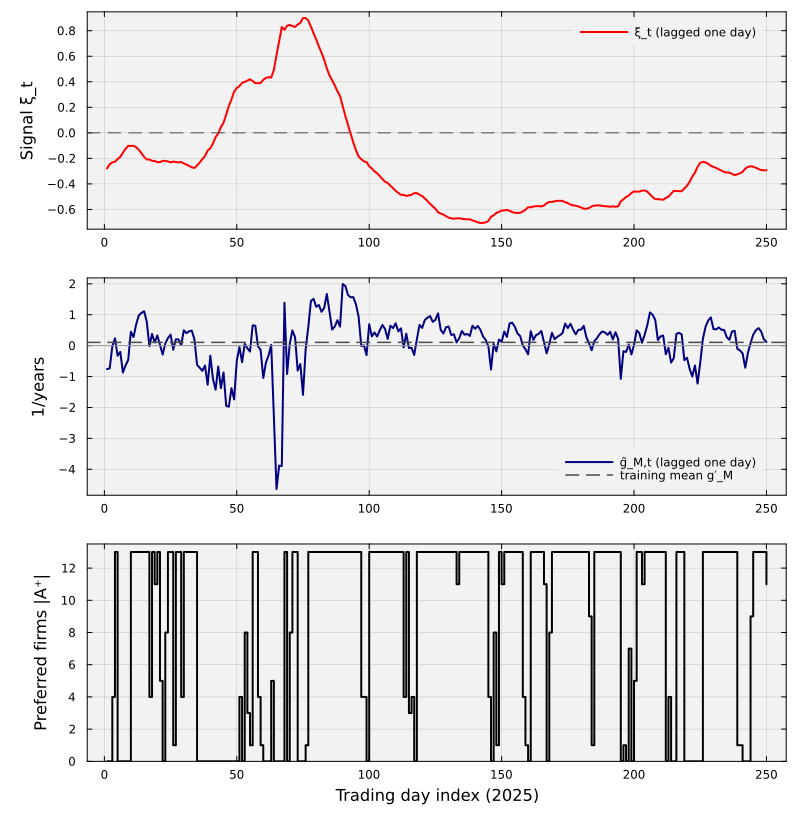

In [10]:
let
    N = length(ξ_lag);
    p1 = plot(1:N, ξ_lag, lw = 2, c = :red, label = "ξ_t (lagged one day)", ylabel = "Signal ξ_t")
    hline!(p1, [0.0], lw = 1, ls = :dash, c = :gray30, label = "")
    plot!(p1, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topright)
    p2 = plot(1:N, g̃_M_lag, lw = 2, c = :navy, label = "g̃_M,t (lagged one day)", ylabel = "1/years")
    hline!(p2, [g_market_mean], lw = 1.5, ls = :dash, c = :gray30, label = "training mean g′_M")
    hline!(p2, [0.0], lw = 1, c = :gray60, label = "")
    plot!(p2, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :bottomright)
    p3 = plot(1:N, [count(Γ[t, :] .> 0) for t ∈ 1:N], lw = 2, c = :black, label = "", ylabel = "Preferred firms |A⁺|", xlabel = "Trading day index (2025)", linetype = :steppost)
    plot!(p3, bg = "gray95", background_color_outside = "white", framestyle = :box, ylim = (0, 13.5))
    plot(p1, p2, p3, layout = (3, 1), size = (800, 820), left_margin = 5Plots.mm)
end

___

## Task 3: The Engine
The engine is [the `run_utility_engine(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.run_utility_engine) of the course package. It is allocator-agnostic: it walks the price matrix day by day and, on days in the reallocation set $\mathcal{R}$ when it is not locked in cash, asks a __target function__ we supply for the desired risky weights. Each day it accrues the cash by $e^{g_{f}\Delta{t}}$, marks the book to market at the day's close prices, and checks the drawdown circuit breaker (if wealth is more than $d_{\max}$ below its running peak, the book is liquidated to cash, bypassing the turnover cap, and the engine is locked for $n_{\text{lock}}$ more days; on the first scheduled trade after the lock the peak is rebased to the current wealth). On a trading day it calls the target function with the day index and the current state (pre-trade wealth, weights, shares, cash, and a copy of the day's execution prices), caps the one-way turnover of the proposed change at $\tau_{\max}$, solves for the cost and the positions together so that the targets are sized on the post-cost budget, and pays the cost $c$ per dollar of gross notional traded.

Our target functions read the lagged preference weights $\gamma_{i}(t)$ from `Γ` and return risky weights: the Cobb–Douglas targets [via `allocate_cobb_douglas(...)`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_cobb_douglas), whose weights among the preferred firms do not depend on prices (only the floors do), and which return floors plus cash on a day when the preferred set is empty, and the CES targets [via `allocate_ces(...)`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_ces) with the engine's elasticity rule $\eta(\xi_{t}) = \eta_{\min} + (\eta_{\max}-\eta_{\min})/(1+|\xi_{t}|)$ evaluated at the lagged signal (these weights depend on the day's closing prices through the bang-for-the-buck ratios; the prices are the execution prices, known when a market-on-close order fills, so the CES variant is next-bar in its signal but same-close in its price inputs, a dependence the Cobb–Douglas variant does not have). Because $\gamma_{i}(t)$ and $\eta(\xi_{t})$ come from the lagged signal, the decision uses no information the investor lacked before the close.

We run adaptive variants and static baselines through the __same__ engine, so every path pays the same costs and follows the same accounting: Cobb–Douglas on the monthly schedule with all rules on (`adaptive, monthly`), on the daily schedule (`adaptive, daily`), monthly with the cap and breaker switched off (`adaptive, monthly, no rules`), monthly with zero costs (`adaptive, monthly, c = 0`), and CES with the elasticity rule on the monthly schedule (`adaptive CES, monthly`); the buy-and-hold GMV, tangent, and equal-weight portfolios (one trade on day 1), the equal-weight portfolio rebalanced monthly, and SPY bought on day 1. We collect the results in the `runs::Dict{String,NamedTuple}` variable:

In [11]:
runs = let
    N = size(S_2025, 1); # trading days in 2025
    R_monthly = collect(1:schedule_days:N); # 𝓡: day 1 and every 21 trading days after it
    R_daily = collect(1:N);

    # target functions: risky weights from the lagged preference weights at the day's execution prices -
    target_cd = (t, state) -> begin
        alloc = allocate_cobb_douglas(state.prices, Γ[t, :], state.wealth; epsilon = n_min);
        alloc.dollars ./ state.wealth; # risky weights of wealth (sum ≤ 1; the remainder is cash)
    end;
    target_ces = (t, state) -> begin
        η_t = η_min + (η_max - η_min)/(1 + abs(ξ_lag[t])); # the engine's elasticity rule at the lagged signal
        alloc = allocate_ces(state.prices, Γ[t, :], state.wealth, η_t; epsilon = n_min);
        alloc.dollars ./ state.wealth;
    end;

    runs = Dict{String, NamedTuple}();
    runs["adaptive, monthly"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    runs["adaptive, daily"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_daily, cost_rate = c, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    runs["adaptive, monthly, no rules"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, turnover_cap = Inf, drawdown_limit = 1.0, g_f = g_f, Δt = Δt);
    runs["adaptive, monthly, c = 0"] = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_monthly, cost_rate = 0.0, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    runs["adaptive CES, monthly"] = run_utility_engine(S_2025, target_ces; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, turnover_cap = τ_max, drawdown_limit = d_max, reentry_days = n_lock, g_f = g_f, Δt = Δt);
    runs["GMV (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_GMV; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["tangent (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_T; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["equal weight (buy and hold)"] = run_utility_engine(S_2025, (t, state) -> w_eq; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs["equal weight (monthly)"] = run_utility_engine(S_2025, (t, state) -> w_eq; W0 = W₀, rebalance_days = R_monthly, cost_rate = c, g_f = g_f, Δt = Δt);
    runs["SPY (buy and hold)"] = run_utility_engine(reshape(spy_2025, :, 1), (t, state) -> [1.0]; W0 = W₀, rebalance_days = [1], cost_rate = c, g_f = g_f, Δt = Δt);
    runs; # return
end;

let
    for name ∈ ["adaptive, monthly", "adaptive, daily", "adaptive CES, monthly"]
        r = runs[name];
        floors_only_days = count(t -> dot(r.shares[t+1, :], S_2025[t, :]) < 0.02*r.wealth[t+1], 1:size(S_2025, 1)); # days the book held only the floors (risky exposure below 2% of wealth) plus cash
        println("$(name): $(count(r.rebalanced)) scheduled rebalances, $(r.interventions) emergency liquidation(s), locked on $(count(r.locked)) days, with risky exposure below 2% of wealth (floors plus cash) on $(floors_only_days) days, total one-way turnover $(round(sum(r.turnover), digits=3)), total cost $(round(sum(r.cost), digits=2)) USD")
    end
end

adaptive, monthly: 12 scheduled rebalances, 0 emergency liquidation(s), locked on 0 days, with risky exposure below 2% of wealth (floors plus cash) on 50 days, total one-way turnover 2.108, total cost 1.9 USD
adaptive, daily: 228 scheduled rebalances, 1 emergency liquidation(s), locked on 22 days, with risky exposure below 2% of wealth (floors plus cash) on 30 days, total one-way turnover 45.69, total cost 38.86 USD
adaptive CES, monthly: 12 scheduled rebalances, 0 emergency liquidation(s), locked on 0 days, with risky exposure below 2% of wealth (floors plus cash) on 50 days, total one-way turnover 2.328, total cost 2.02 USD


___

## Task 4: Wealth and Weights Through the Year
`Unhide` the code block below to see how we visualized the scaled wealth $W_{\mathcal{P}}(t)/W_{\mathcal{P}}(0)$ of every run through 2025. If the monthly adaptive engine's circuit breaker fires, the days it then spends locked in cash are shaded; in this run it never fired, so there is no shading, and the days the engine spent out of the market are the days the model emptied the basket (see the weights chart below).

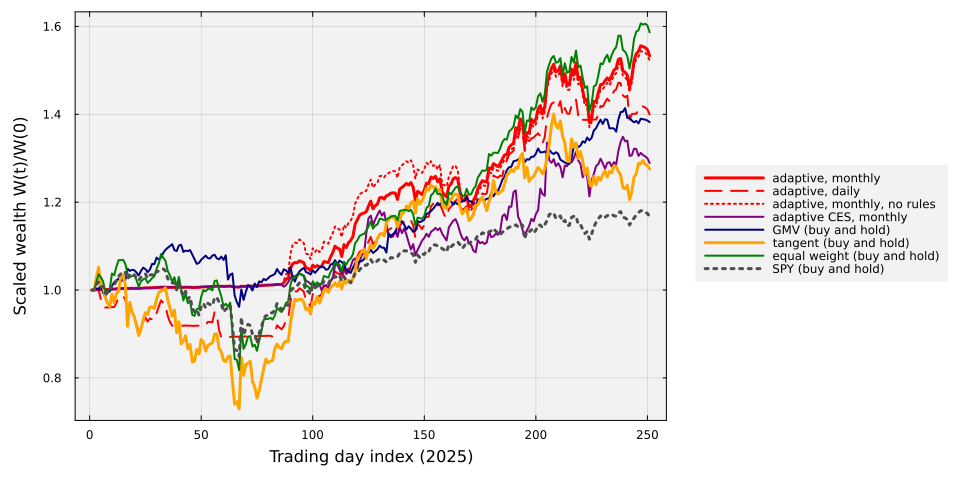

In [12]:
let
    styles = [("adaptive, monthly", :red, :solid, 3), ("adaptive, daily", :red, :dash, 2), ("adaptive, monthly, no rules", :red, :dot, 2), ("adaptive CES, monthly", :purple, :solid, 2),
        ("GMV (buy and hold)", :navy, :solid, 2), ("tangent (buy and hold)", :orange, :solid, 3), ("equal weight (buy and hold)", :green, :solid, 2), ("SPY (buy and hold)", :gray30, :dot, 3)];
    p = plot();
    for (name, color, style, width) ∈ styles
        plot!(p, runs[name].wealth ./ W₀, lw = width, c = color, ls = style, label = name)
    end
    r = runs["adaptive, monthly"];
    locked_days = findall(r.locked); # days the monthly engine sat in cash after the breaker fired
    first_span = true;
    while !isempty(locked_days) # shade each contiguous locked run separately
        stop = 1;
        while stop < length(locked_days) && locked_days[stop + 1] == locked_days[stop] + 1
            stop += 1;
        end
        vspan!(p, [locked_days[1], locked_days[stop] + 1], c = :gray, alpha = 0.15, label = first_span ? "breaker: monthly engine in cash" : "")
        first_span = false;
        locked_days = locked_days[(stop + 1):end];
    end
    plot!(p, xlabel = "Trading day index (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :outerright, size = (960, 480),
        left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

`Unhide` the code block below to see the risky weights and the cash fraction of the monthly adaptive engine through the year (a stacked area chart; the vertical lines mark the rebalance days). Two features of the chart are the model and the rules at work: the book holds only the floors plus cash on scheduled days when the preferred set is empty (the model saying that this basket does not belong in that market), and it is only half invested for the first weeks after such a day, because the turnover cap $\tau_{\max} = 0.5$ applies to every scheduled trade and moving all of the wealth from cash into risky assets is a one-way turnover of one, so the rest of the entry waits for the next scheduled day. (Had the circuit breaker fired, its lock would also show as an all-cash stretch; in this run it did not.) The rules interact, and the chart is where you see it.

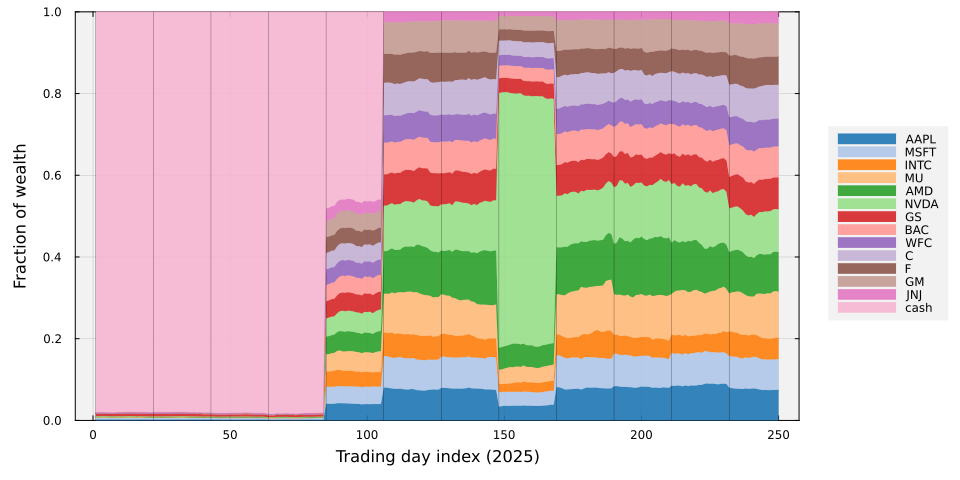

In [13]:
let
    r = runs["adaptive, monthly"];
    N = size(S_2025, 1);
    W = hcat(r.weights[2:end, :], r.cash[2:end] ./ r.wealth[2:end]); # N × (|𝒫| + 1): risky weights then cash
    labels = permutedims(vcat(my_list_of_tickers, "cash"));
    p = areaplot(1:N, W, labels = labels, lw = 0.5, palette = :tab20, fillalpha = 0.9,
        xlabel = "Trading day index (2025)", ylabel = "Fraction of wealth", ylim = (0, 1),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :outerright, size = (960, 480), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
    vline!(p, findall(r.rebalanced), lw = 0.5, c = :black, alpha = 0.5, label = "")
    p
end

___

## Task 5: The Realized-Path Scorecard
Finally, we score every run on the realized 2025 path (horizon $T = N\Delta{t}$ years for $N = 250$ trading days) [using the `realized_scorecard(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.realized_scorecard): terminal wealth $W_{\mathcal{P}}(T)$, the portfolio NPV against the risk-free baseline $\text{NPV} = -W_{\mathcal{P}}(0) + W_{\mathcal{P}}(T)e^{-g_{f}T}$ (a positive value means the run beat holding cash at $g_{f}$), the maximum drawdown, the realized growth rate $\ln(W_{\mathcal{P}}(T)/W_{\mathcal{P}}(0))/T$, the annualized realized Sharpe ratio of the daily wealth growth in excess of $g_{f}$, the total one-way turnover, the total cost, and the number of circuit-breaker interventions. Note that a drawdown limit of 10% does not cap the realized drawdown at 10%: the breaker is checked once a day, after the loss has happened, and the liquidation itself pays a cost, so the recorded maximum drawdown of a run with the breaker on is somewhat larger than $d_{\max}$. One path is one draw: these numbers say what happened in 2025, not how likely it was, and quantities such as a fail rate or a tail quantile of terminal wealth need many paths, which is the subject of L7b. We store the table in the `scorecard::DataFrame` variable:

In [14]:
scorecard = let
    order = ["adaptive, monthly", "adaptive, daily", "adaptive, monthly, no rules", "adaptive, monthly, c = 0", "adaptive CES, monthly",
        "GMV (buy and hold)", "tangent (buy and hold)", "equal weight (buy and hold)", "equal weight (monthly)", "SPY (buy and hold)"];
    df = DataFrame(run = String[], W_T = Float64[], NPV = Float64[], max_drawdown = Float64[], growth = Float64[], sharpe = Float64[], turnover = Float64[], cost = Float64[], interventions = Int[]);
    for name ∈ order
        r = runs[name];
        sc = realized_scorecard(r.wealth; g_f = g_f, Δt = Δt, turnover = r.turnover, cost = r.cost, interventions = r.interventions);
        push!(df, (run = name, W_T = round(sc.terminal, digits=2), NPV = round(sc.npv, digits=2), max_drawdown = round(sc.max_drawdown, digits=4),
            growth = round(sc.realized_growth, digits=4), sharpe = round(sc.realized_sharpe, digits=3), turnover = round(sc.total_turnover, digits=3), cost = round(sc.total_cost, digits=2), interventions = sc.interventions));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    df; # return
end;

 ----------------------------- --------- --------- -------------- --------- --------- ---------- --------- ---------------
                          run       W_T       NPV   max_drawdown    growth    sharpe   turnover      cost   interventions 
                       String   Float64   Float64        Float64   Float64   Float64    Float64   Float64           Int64 
 ----------------------------- --------- --------- -------------- --------- --------- ---------- --------- ---------------
            adaptive, monthly    1533.3    472.18         0.0898    0.4308     2.529      2.108       1.9               0
              adaptive, daily   1399.51    343.72          0.108    0.3388     1.705      45.69     38.86               1
  adaptive, monthly, no rules    1521.5    460.86         0.0898    0.4231     2.273      2.916      2.87               0
     adaptive, monthly, c = 0   1535.78    474.57         0.0898    0.4325     2.541      2.108       0.0               0
        adaptive CES

Read the table across: which runs beat cash (positive NPV), how the drawdown limit traded away drawdown for terminal wealth, what a monthly versus a daily schedule cost in turnover, and how many days each adaptive engine spent out of the market because the model classified the whole basket as non-preferred. Then read it against the buy-and-hold rows: the static portfolios paid one round of costs and took whatever 2025 gave them, while the engine paid to move.

To isolate what the rules and the cost rate do, we run the monthly Cobb–Douglas engine with the two rules on and off, at cost rates of 0, 5, and 20 basis points, and report terminal wealth, drawdown, turnover, cost, and interventions:

In [15]:
let
    N = size(S_2025, 1);
    R_monthly = collect(1:schedule_days:N);
    target_cd = (t, state) -> begin
        alloc = allocate_cobb_douglas(state.prices, Γ[t, :], state.wealth; epsilon = n_min);
        alloc.dollars ./ state.wealth;
    end;
    df = DataFrame(rules = String[], cost_bp = Int[], W_T = Float64[], NPV = Float64[], max_drawdown = Float64[], turnover = Float64[], cost = Float64[], interventions = Int[]);
    for (rules, cap, dd) ∈ [("on", τ_max, d_max), ("off", Inf, 1.0)], cost_bp ∈ [0, 5, 20]
        r = run_utility_engine(S_2025, target_cd; W0 = W₀, rebalance_days = R_monthly, cost_rate = cost_bp*1e-4, turnover_cap = cap, drawdown_limit = dd, reentry_days = n_lock, g_f = g_f, Δt = Δt);
        sc = realized_scorecard(r.wealth; g_f = g_f, Δt = Δt, turnover = r.turnover, cost = r.cost, interventions = r.interventions);
        push!(df, (rules = rules, cost_bp = cost_bp, W_T = round(sc.terminal, digits=2), NPV = round(sc.npv, digits=2), max_drawdown = round(sc.max_drawdown, digits=4), turnover = round(sc.total_turnover, digits=3), cost = round(sc.total_cost, digits=2), interventions = sc.interventions));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- -------------- ---------- --------- ---------------
   rules   cost_bp       W_T       NPV   max_drawdown   turnover      cost   interventions 
  String     Int64   Float64   Float64        Float64    Float64   Float64           Int64 
 -------- --------- --------- --------- -------------- ---------- --------- ---------------
      on         0   1535.78    474.57         0.0898      2.108       0.0               0
      on         5    1533.3    472.18         0.0898      2.108       1.9               0
      on        20   1525.88    465.06         0.0898      2.108      7.56               0
     off         0   1525.18    464.39         0.0898      2.916       0.0               0
     off         5    1521.5    460.86         0.0898      2.916      2.87               0
     off        20   1510.52    450.32         0.0937      2.916     11.45               0
 -------- --------- --------- --------- -------------- ---------- --------- ----------

___

## Summary
In this example, we ran the maximum-utility rebalancing engine through 2025 with one-day-lagged market inputs, a reallocation schedule, a turnover cap, and a drawdown circuit breaker, and scored it on the realized path against static portfolios run through the same accounting.

> __Key Takeaways:__
>
> * __The decision rule is lagged and the accounting is self-financing:__ the market inputs and the preference weights on each day use prices through the previous day (asserted in code), the trade executes at that day's close, and the cost and the positions are solved together so that the targets are sized on the post-cost budget and cash never goes negative.
> * __The model chooses the basket before the rules shape the path:__ on scheduled days when the recent market growth puts every firm below its threshold, the engine holds the floors plus cash, which is the model's statement that this basket does not belong in that market; the schedule sets how often the engine may act on that, the turnover cap bounds how far it moves at once, and the circuit breaker converts a large drawdown into a period in cash.
> * __A realized-path scorecard is one draw:__ terminal wealth, NPV against cash, drawdown, realized growth and Sharpe ratio, turnover, and cost describe what happened this year; a distribution of outcomes needs many simulated paths, which is where L7b takes the engine.

Next, in L7b, we let the SIM parameters themselves update as the year unfolds and compare the frozen and updated engines path by path.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___